# Synthetic data: evaluation of the presence of propagation in Simulations

## SPI vs NI

In [15]:
import os
import pandas as pd
import io

directory = "/sise/assafzar-group/assafzar/CellDeathData/Synthetic_Data/DataSimalution1225"



# List files in the directory
files = os.listdir(directory)

# Extract information from each file
file_info = []
for file in files:
    file_path = f"{directory}/{file}"
    df = pd.read_csv(file_path)
    df.rename(columns={"x": "cell_x", "y": "cell_y"}, inplace=True)
    try:
        df.drop(columns=[ "Unnamed: 0"], inplace=True)
    except:
        pass
    df.to_csv(file_path, index=False)
    name = file.split('.csv')[0]
    treatment = f"nuc={name.split('nuc_')[-1].split('_prop_')[0]},prop={name.split('prop_')[-1]}"
    density = len(df)
    file_info.append({"File Name": file,"Cell Line": "None", "Treatment": treatment, "Density": density, "Time Interval (min)":1})



# Create a DataFrame with the extracted information
file_info_df = pd.DataFrame(file_info)
print(file_info_df)

                 File Name Cell Line           Treatment  Density  \
0   nuc_0.005_prop_0.2.csv      None  nuc=0.005,prop=0.2     1000   
1     nuc_0.005_prop_0.csv      None    nuc=0.005,prop=0     1000   
2   nuc_0.005_prop_0.5.csv      None  nuc=0.005,prop=0.5     1000   
3    nuc_0.01_prop_0.2.csv      None   nuc=0.01,prop=0.2     1000   
4      nuc_0.01_prop_0.csv      None     nuc=0.01,prop=0     1000   
5    nuc_0.01_prop_0.5.csv      None   nuc=0.01,prop=0.5     1000   
6      nuc_0.04_prop_0.csv      None     nuc=0.04,prop=0     1000   
7       nuc_0.1_prop_0.csv      None      nuc=0.1,prop=0     1000   
8    nuc_0.04_prop_0.2.csv      None   nuc=0.04,prop=0.2     1000   
9    nuc_0.04_prop_0.5.csv      None   nuc=0.04,prop=0.5     1000   
10    nuc_0.1_prop_0.2.csv      None    nuc=0.1,prop=0.2     1000   
11    nuc_0.1_prop_0.5.csv      None    nuc=0.1,prop=0.5     1000   

    Time Interval (min)  
0                     1  
1                     1  
2                     1 

In [16]:
file_info_df.to_csv(f"/sise/assafzar-group/assafzar/CellDeathData/Synthetic_Data/file_info.csv", index=False)

In [1]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mixSpiCalc import mixSpiCalc

In [8]:
only_recent_death_flag_for_neighbors_calc = False
neighbors_dist_threshold = 100
sliding_time_window_size = 1
exps_dir_name = "/sise/assafzar-group/assafzar/CellDeathData/Synthetic_Data/DataSimalution1225"
meta_data_file_full_path = "/sise/assafzar-group/assafzar/CellDeathData/Synthetic_Data/file_info.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,0]
meta_data_df = pd.read_csv(meta_data_file_full_path)
all_previous_experiments_spi_and_ni_regeneration = calc_all_experiments_SPI_and_NI_for_landscape(
        exp_name=list(exp_names),
        exps_dir_path=exps_dir_name,
        meta_data_full_file_path=meta_data_file_full_path,
        dist_threshold=neighbors_dist_threshold,
        only_recent_death_flag_for_neighbors_calc=only_recent_death_flag_for_neighbors_calc,
        time_unit="frames",
        sliding_time_window_size=sliding_time_window_size
    )


In [9]:
reformatting_all_previos_experiments_spi_and_ni_regeneration = {"Experiment_name":[],
                                                                "SPI":[],
                                                                "NI":[],
                                                                "Treatment":[],
                                                                "Cell Line + Treatment":[],
                                                                "Cell Line":[], 
                                                                "Mode":[],
                                                                "Density":[]}

for key,value in all_previous_experiments_spi_and_ni_regeneration.items():
    if value is None:
        continue
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Experiment_name"].append(key)
    exp_cell_line= meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"]== key]["Cell Line"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration['Mode'].append('artificial')  
    reformatting_all_previos_experiments_spi_and_ni_regeneration["SPI"].append(value[0])
    reformatting_all_previos_experiments_spi_and_ni_regeneration["NI"].append(value[1])
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line"].append(exp_cell_line)
    treatment_  = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"]== key]["Treatment"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line + Treatment"].append(treatment_ )
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Treatment"].append(treatment_)
    density = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Density"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Density"].append(density)
    

In [10]:
reformatting_all_previos_experiments_spi_and_ni_regeneration_df = pd.DataFrame(reformatting_all_previos_experiments_spi_and_ni_regeneration)
reformatting_all_previos_experiments_spi_and_ni_regeneration_df

,Experiment_name,SPI,NI,Treatment,Cell Line + Treatment,Cell Line,Mode,Density
0,nuc_0.005_prop_0.2.csv,0.340680,0.066,"nuc=0.005,prop=0.2","nuc=0.005,prop=0.2",NaN,artificial,1000
1,nuc_0.005_prop_0.csv,-0.038348,0.164,"nuc=0.005,prop=0","nuc=0.005,prop=0",NaN,artificial,1000
2,nuc_0.005_prop_0.5.csv,0.441373,0.060,"nuc=0.005,prop=0.5","nuc=0.005,prop=0.5",NaN,artificial,1000
3,nuc_0.01_prop_0.2.csv,0.251187,0.087,"nuc=0.01,prop=0.2","nuc=0.01,prop=0.2",NaN,artificial,1000
4,nuc_0.01_prop_0.csv,-0.032079,0.155,"nuc=0.01,prop=0","nuc=0.01,prop=0",NaN,artificial,1000
5,nuc_0.01_prop_0.5.csv,0.359714,0.068,"nuc=0.01,prop=0.5","nuc=0.01,prop=0.5",NaN,artificial,1000
6,nuc_0.04_prop_0.csv,-0.006330,0.154,"nuc=0.04,prop=0","nuc=0.04,prop=0",NaN,artificial,1000
7,nuc_0.1_prop_0.csv,-0.018944,0.159,"nuc=0.1,prop=0","nuc=0.1,prop=0",NaN,artificial,1000
8,nuc_0.04_prop_0.2.csv,0.111065,0.127,"nuc=0.04,prop=0.2","nuc=0.04,prop=0.2",NaN,artificial,1000
9,nuc_0.04_prop_0.5.csv,0.190343,0.116,"nuc=0.04,prop=0.5","nuc=0.04,prop=0.5",NaN,artificial,1000


In [11]:
reformatting_all_previos_experiments_spi_and_ni_regeneration_df["Nuc"]= reformatting_all_previos_experiments_spi_and_ni_regeneration_df["Treatment"].apply(lambda x: float(x.split('nuc=')[-1].split(',')[0]))
reformatting_all_previos_experiments_spi_and_ni_regeneration_df["Prop"]= reformatting_all_previos_experiments_spi_and_ni_regeneration_df["Treatment"].apply(lambda x: float(x.split('prop=')[-1]))

In [30]:
reformatting_all_previos_experiments_spi_and_ni_regeneration_df

,Experiment_name,SPI,NI,Treatment,Cell Line + Treatment,Cell Line,Mode,Density,Nuc,Prop
0,nuc_0.005_prop_0.2.csv,0.339677,0.168,"nuc=0.005,prop=0.2","nuc=0.005,prop=0.2",NaN,artificial,1000,0.005,0.2
1,nuc_0.005_prop_0.csv,-0.037366,0.168,"nuc=0.005,prop=0","nuc=0.005,prop=0",NaN,artificial,1000,0.005,0.0
2,nuc_0.005_prop_0.5.csv,0.459146,0.212,"nuc=0.005,prop=0.5","nuc=0.005,prop=0.5",NaN,artificial,1000,0.005,0.5
3,nuc_0.01_prop_0.2.csv,0.258096,0.175,"nuc=0.01,prop=0.2","nuc=0.01,prop=0.2",NaN,artificial,1000,0.010,0.2
4,nuc_0.01_prop_0.csv,-0.032943,0.173,"nuc=0.01,prop=0","nuc=0.01,prop=0",NaN,artificial,1000,0.010,0.0
5,nuc_0.01_prop_0.5.csv,0.391304,0.210,"nuc=0.01,prop=0.5","nuc=0.01,prop=0.5",NaN,artificial,1000,0.010,0.5
6,nuc_0.04_prop_0.csv,-0.009642,0.179,"nuc=0.04,prop=0","nuc=0.04,prop=0",NaN,artificial,1000,0.040,0.0
7,nuc_0.1_prop_0.csv,-0.028233,0.209,"nuc=0.1,prop=0","nuc=0.1,prop=0",NaN,artificial,1000,0.100,0.0
8,nuc_0.04_prop_0.2.csv,0.100497,0.200,"nuc=0.04,prop=0.2","nuc=0.04,prop=0.2",NaN,artificial,1000,0.040,0.2
9,nuc_0.04_prop_0.5.csv,0.104348,0.244,"nuc=0.04,prop=0.5","nuc=0.04,prop=0.5",NaN,artificial,1000,0.040,0.5


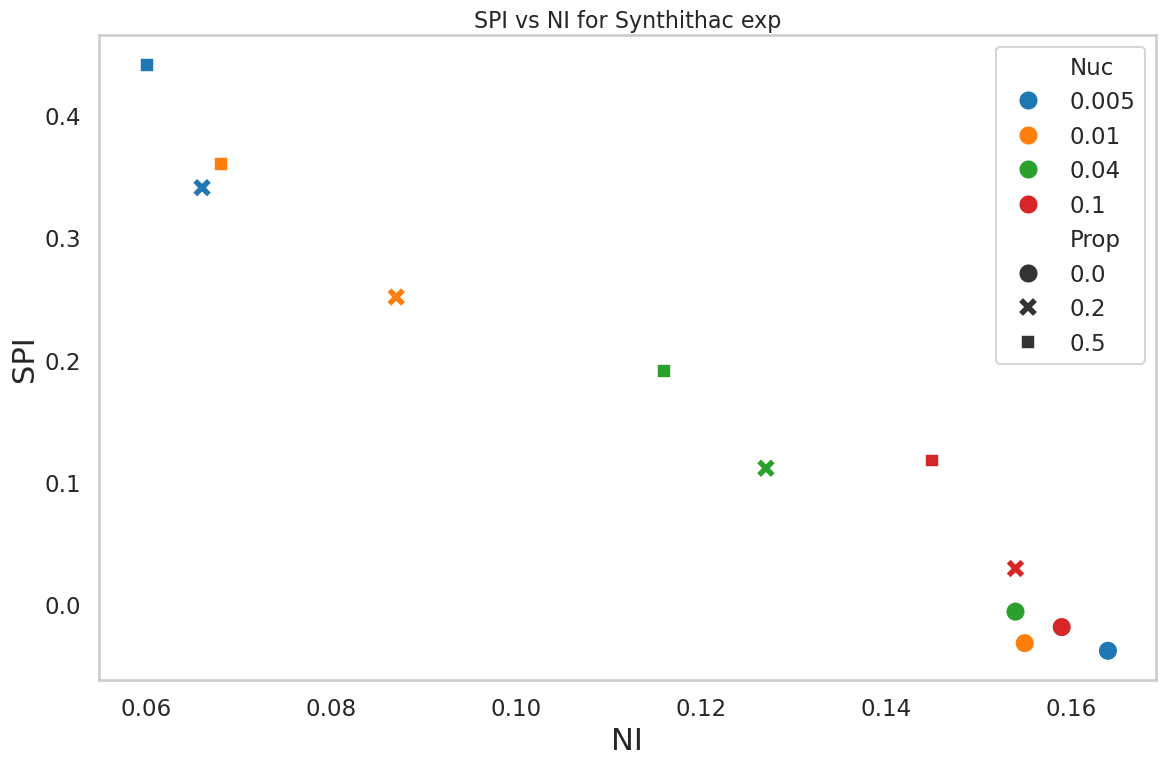

In [12]:
def plot_spi_vs_ni(dataframe):
    """
    Plots SPI vs NI for pure and mixed colonies based on the 'Mode' column and uses 'Experiment_name' as marker style.

    Parameters:
    - dataframe: pandas DataFrame containing SPI, NI, Mode, and Experiment_name columns.
    """
    sns.set_palette("colorblind")
    sns.set_context("talk")
    sns.set_style("whitegrid")

    plt.figure(figsize=(12, 8))
    ax = sns.scatterplot(
        data=dataframe,
        x="NI",
        y="SPI",
        hue="Nuc",
        style="Prop",
        s=200, 
        palette="tab10"
    )

    plt.title("SPI vs NI for Synthithac exp", fontsize=16)
    plt.xlabel("NI", fontsize=22)
    plt.ylabel("SPI", fontsize=22)
    # ax.legend_.remove()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# Example usage
plot_spi_vs_ni(reformatting_all_previos_experiments_spi_and_ni_regeneration_df)


## NRF

In [ ]:
meta_data_file_path = "/sise/assafzar-group/assafzar/CellDeathData/Synthetic_Data/file_info.csv"
root_results_dir = "/home/esraan/CellDeathSpreading/results"
exp_names = meta_data_extract_exp_names.iloc[:,0]
for sliding_time_window_size in (10, 15, 20, 30): #
    print(f"calculating NRF with sliding time window: {sliding_time_window_size}")
    dir_path_to_save_nrf_plots = os.path.join(
        root_results_dir,
        f"sliding_time_window_{sliding_time_window_size}" if sliding_time_window_size is not None else f"no_sliding_time_window"
    )
    exps_results_dicts = calc_factor_of_propagation_by_number_of_dead_neighbors_and_time_from_recent_neighbors_death(
        dir_path_to_save_nrf_plots=dir_path_to_save_nrf_plots,
        exp_name=list(exp_names),
        exps_dir_path= exps_dir_name,
        max_number_of_dead_neighbors_to_calc=5,
        max_delta_tod_from_recently_dead_neighbor=5,
        meta_data_full_file_path=meta_data_file_path,
        save_fig=True,
        show_fig=True,
        sliding_time_window_size=sliding_time_window_size,
        number_of_random_permutations=1000,
        include_only_treatments=['nuc'],
        fig_v_min=1.,
        fig_v_max=3.
    )